In [1]:
from cnn import run_pipeline
from feature_extraction import get_feature

Backend: GPU (CuPy)


In [2]:
data = get_feature("plp_40")

Found 32978 audio files.

Counts by label:
 label
1    27605
0     5373
Name: count, dtype: int64

Counts by source:
 source
music_ldm            5521
audio_ldm2           5521
mustango             5521
music_gen_medium     5521
stable_audio_open    5521
music_caps           5373
Name: count, dtype: int64
After balancing: 10,743 clips
label
Human    5373
AI       5370
Name: count, dtype: int64

AI-side breakdown:
source
audio_ldm2           1074
stable_audio_open    1074
music_ldm            1074
mustango             1074
music_gen_medium     1074
Name: count, dtype: int64
[train] [1/7520] Processed: dataset\stable_audio_open\QmIhKF1BqCg.wav  (2 chunk(s))
[train] [2/7520] Processed: dataset\music_caps\Y5RVYmf3uWc.wav  (2 chunk(s))
[train] [3/7520] Processed: dataset\audio_ldm2\uCCdUB7D10U.wav  (2 chunk(s))
[train] [4/7520] Processed: dataset\music_ldm\aq3vov8-fw8.wav  (2 chunk(s))
[train] [5/7520] Processed: dataset\mustango\9ziKfjHWqZ0.wav  (2 chunk(s))
[train] [6/7520] Processed: dat

In [3]:
train_x, train_y, train_s = data["train"]
val_x,   val_y,   val_s   = data["val"]
test_x,  test_y,  test_s  = data["test"]

Using device: GPU (CuPy)
train_x shape: (15038, 1, 40, 313)
Number of classes: 2
CNNModel(
  (features)
    Conv2d
    BatchNorm2d
    ReLU
    MaxPool2d
    Conv2d
    BatchNorm2d
    ReLU
    MaxPool2d
    Conv2d
    BatchNorm2d
    ReLU
    AdaptiveAvgPool2d
  (classifier)
    Flatten
    Linear
    ReLU
    Dropout
    Linear
    ReLU
    Dropout
    Linear
)

Epoch [1/50]
  Train — Loss: 0.6906  Acc: 0.6100
  Val   — Loss: 0.6451  Acc: 0.6372
  ✓ Best model saved → best_plp_40_model.npz

Epoch [2/50]
  Train — Loss: 0.6450  Acc: 0.6425
  Val   — Loss: 0.6397  Acc: 0.6453
  ✓ Best model saved → best_plp_40_model.npz

Epoch [3/50]
  Train — Loss: 0.6289  Acc: 0.6630
  Val   — Loss: 0.6404  Acc: 0.6552

Epoch [4/50]
  Train — Loss: 0.6165  Acc: 0.6764
  Val   — Loss: 0.6214  Acc: 0.6884
  ✓ Best model saved → best_plp_40_model.npz

Epoch [5/50]
  Train — Loss: 0.6091  Acc: 0.6859
  Val   — Loss: 0.6122  Acc: 0.6949
  ✓ Best model saved → best_plp_40_model.npz

Epoch [6/50]
  Train — 

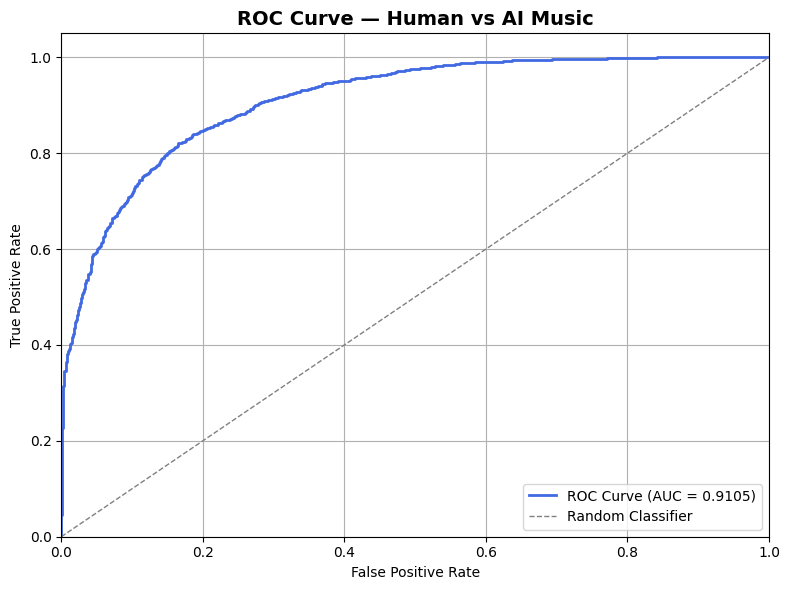

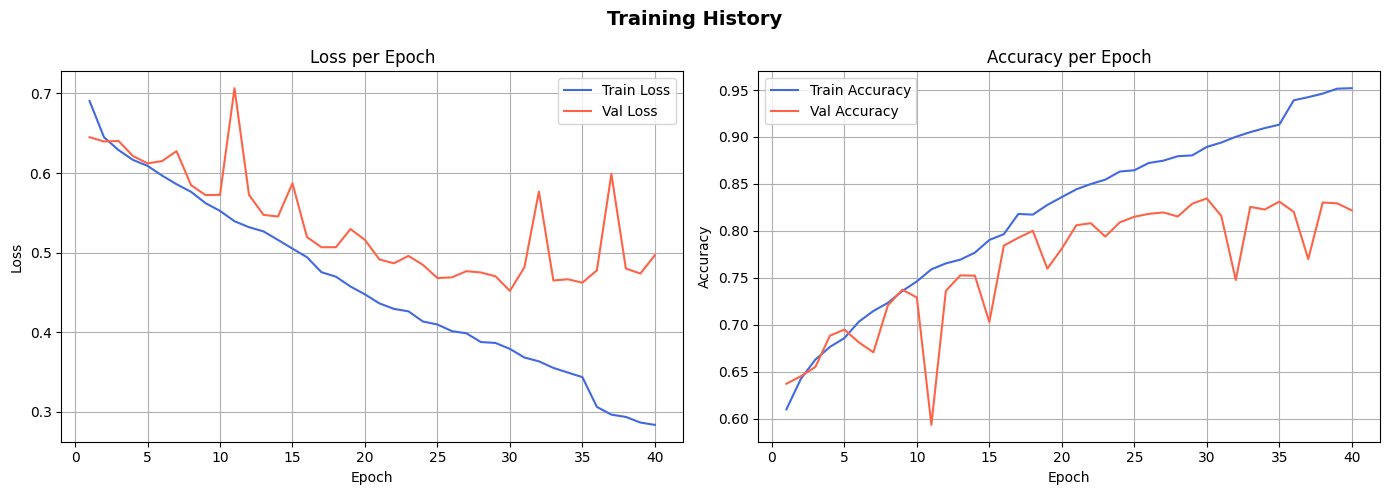

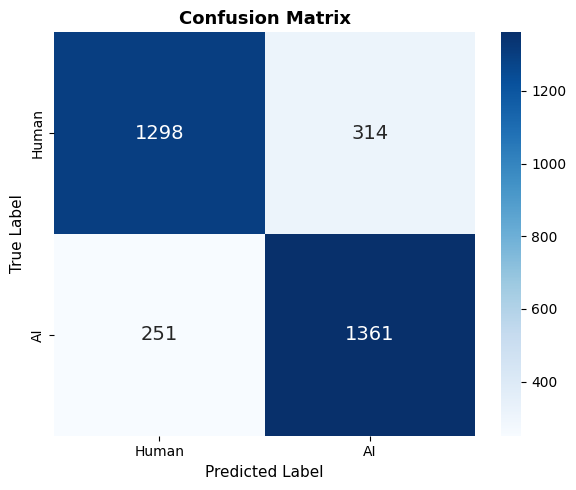

In [4]:
run_pipeline(
    train_x, train_y,
    val_x,   val_y,
    test_x,  test_y,
    labels     = ["Human", "AI"],
    scenario   = "plp_40",
    train_s    = train_s,
    val_s      = val_s,
    test_s     = test_s,
)